# **Exploratory Data Analysis: Biological vs Plastic**

## Import Libraries

In [7]:
# Import Libraries
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageEnhance
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

In [8]:
# Set paths
biological_dir = '../dataset/biological'
plastic_dir = '../dataset/plastic'

valid_ext = ('.jpg', '.jpeg', '.png', '.bmp', 'webp')

def get_paths(folder):
    return [
        os.path.join(folder, f)
        for f in os.listdir(folder)
        if f.lower().endswith(valid_ext)
    ]

bio_paths = get_paths(biological_dir)
pla_paths = get_paths(plastic_dir)
total = len(bio_paths) + len(pla_paths)

print(f"Biological: {len(bio_paths)} images")
print(f"Plastic: {len(pla_paths)} images")
print(f"Total images: {total}")

Biological: 985 images
Plastic: 865 images
Total images: 1850


## Data Cleaning and Preprocessing

In [ ]:
# Check and removed corruped images
def check_and_clean(img_paths, folder_name):
    corrupt = []
    for path in img_paths:
        try:
            img = Image.open(path)
            img.verify()  # Check if file is valid
        except Exception:
            corrupt.append(path)

    print(f'--- {folder_name} ---')
    print(f'  Total checked  : {len(img_paths)}')
    print(f'  Corrupt found  : {len(corrupt)}')

    if corrupt:
        print('  Removing corrupt files...')
        for path in corrupt:
            os.remove(path)
            print(f'Removed: {os.path.basename(path)}')
        print(f'Removed {len(corrupt)} corrupt files')
    else:
        print('No corrupt files found dataset is clean!')

    return corrupt

bc = check_and_clean(bio_paths, 'Biological')
print()
pc = check_and_clean(pla_paths, 'Plastic')

# Reload paths after cleaning
bio_paths = get_paths(biological_dir)
pla_paths = get_paths(plastic_dir)
total     = len(bio_paths) + len(pla_paths)
print(f'\nClean dataset: {len(bio_paths)} bio + {len(pla_paths)} plastic = {total} total')

--- Biological ---
  Total checked  : 985
  Corrupt found  : 0
No corrupt files found dataset is clean!

--- Plastic ---
  Total checked  : 865
  Corrupt found  : 0
No corrupt files found dataset is clean!

Clean dataset: 985 bio + 865 plastic = 1850 total


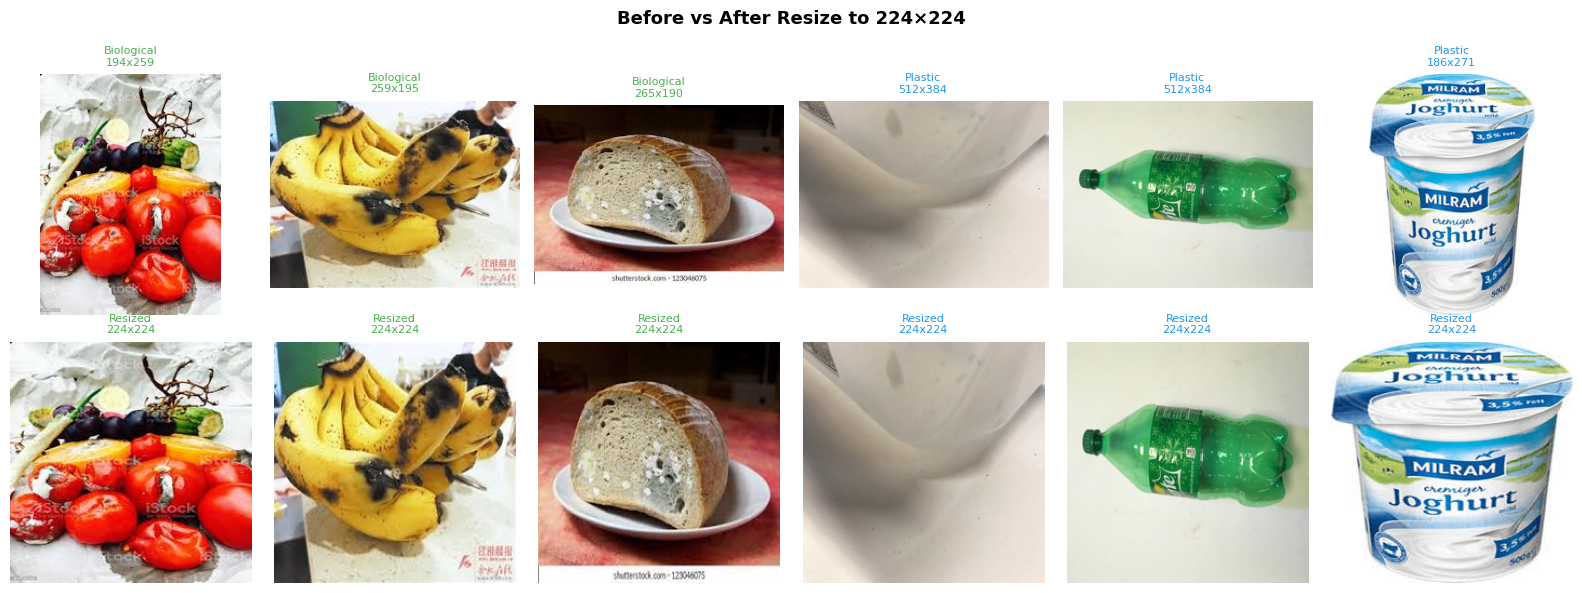

In [10]:
# Preview Resize to 224x224
random.seed(42)

TARGET_SIZE = (224, 224)

bio_sample = random.sample(bio_paths, 3)
pla_sample = random.sample(pla_paths, 3)
all_samples = bio_sample + pla_sample
labels      = ['Biological'] * 3 + ['Plastic'] * 3
label_colors= ['#4CAF50'] * 3 + ['#2196F3'] * 3

fig, axes = plt.subplots(2, 6, figsize=(16, 6))
fig.suptitle('Before vs After Resize to 224×224',
             fontsize=13, fontweight='bold')

for col, (path, label, color) in enumerate(zip(all_samples, labels, label_colors)):
    original = Image.open(path).convert('RGB')
    resized  = original.resize(TARGET_SIZE, Image.LANCZOS)

    # Original
    axes[0][col].imshow(original)
    axes[0][col].axis('off')
    axes[0][col].set_title(
        f'{label}\n{original.size[0]}x{original.size[1]}',
        color=color, fontsize=8
    )

    # Resized
    axes[1][col].imshow(resized)
    axes[1][col].axis('off')
    axes[1][col].set_title(
        f'Resized\n224x224',
        color=color, fontsize=8
    )

axes[0][0].set_ylabel('Original', fontsize=10, fontweight='bold')
axes[1][0].set_ylabel('224×224', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Exploratory Data Analysis (EDA)

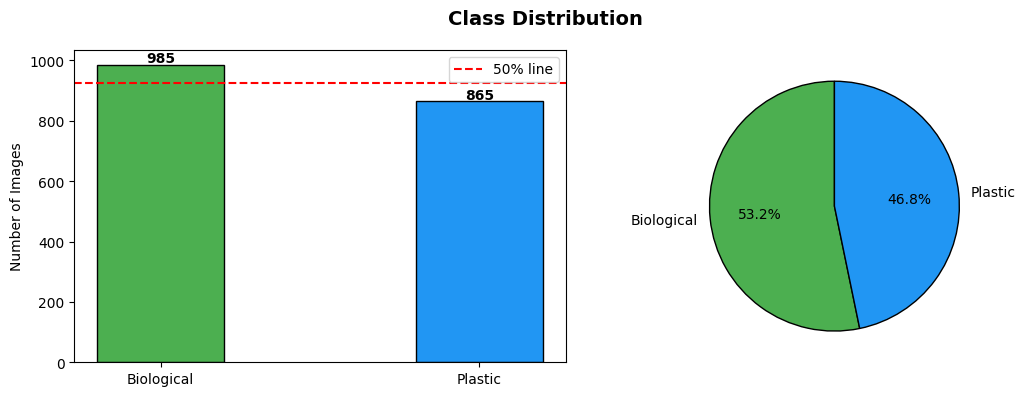

In [11]:
# Class Distribution
counts = {
    'Biological': len(bio_paths),
    'Plastic': len(pla_paths)
}
colors = ['#4CAF50', '#2196F3']

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle('Class Distribution', fontsize=14, fontweight='bold')

# Bar chart
bars = axes[0].bar(counts.keys(), counts.values(), 
                   color=colors, edgecolor='black', width=0.4)
axes[0].axhline(total / 2, color='red', linestyle='--', label='50% line')
axes[0].set_ylabel('Number of Images')
axes[0].legend()
for bar in bars:
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 8,
        str(int(bar.get_height())),
        ha='center', fontweight='bold'
    )

# Pie chart
axes[1].pie(
    counts.values(), labels=counts.keys(),
    colors=colors, autopct='%1.1f%%',
    startangle=90, wedgeprops={'edgecolor': 'black'}
)

plt.tight_layout()
plt.show()

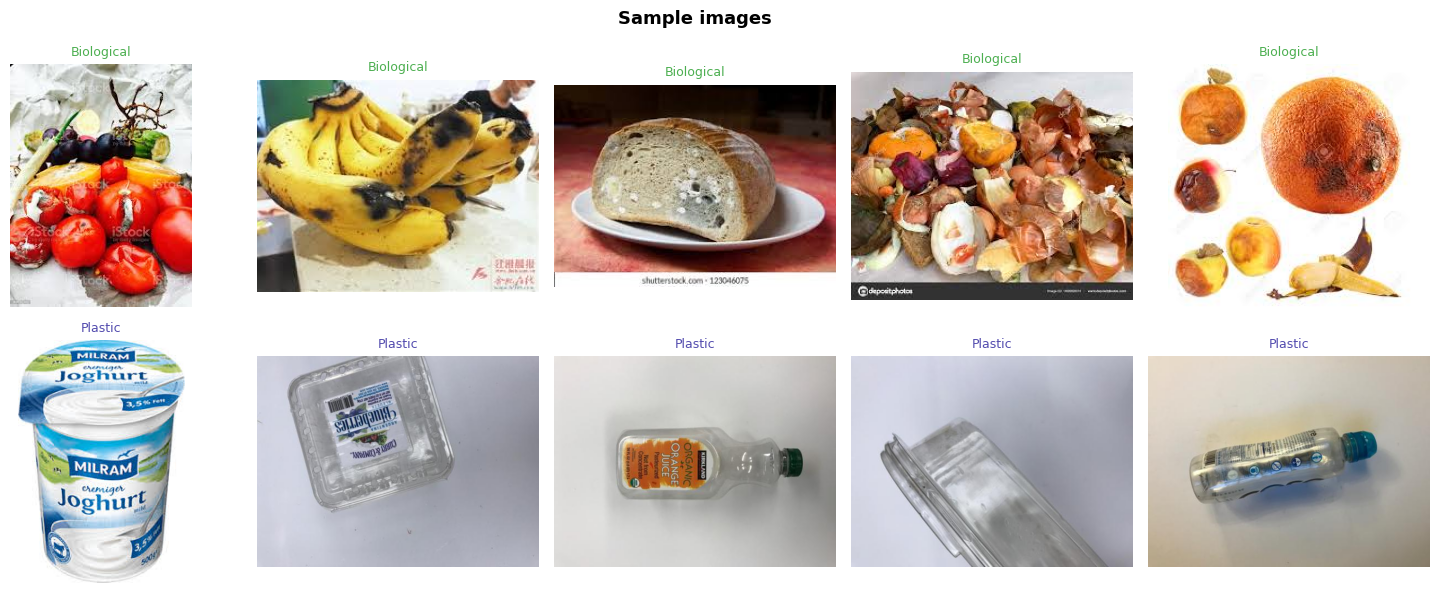

In [12]:
# Sample Images
random.seed(42)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Sample images', fontsize=13, fontweight='bold')

for col, path in enumerate(random.sample(bio_paths, 5)):
    axes[0][col].imshow(Image.open(path).convert('RGB'))
    axes[0][col].axis('off')
    axes[0][col].set_title('Biological', color='#4CAF50', fontsize=9)

for col, path in enumerate(random.sample(pla_paths, 5)):
    axes[1][col].imshow(Image.open(path).convert('RGB'))
    axes[1][col].axis('off')
    axes[1][col].set_title('Plastic', color="#534CAF", fontsize=9)

plt.tight_layout()
plt.show()

In [13]:
# Image size & Corrupt Check
def get_image_stats(img_paths):
    widths, heights, corrupt = [], [], []
    for path in img_paths:
        try:
            w, h = Image.open(path).size
            widths.append(w)
            heights.append(h)
        except:
            corrupt.append(os.path.basename(path))
    return widths, heights, corrupt

bw, bh, bc = get_image_stats(bio_paths)
pw, ph, pc = get_image_stats(pla_paths)

print('--- Biological ---')
print(f'  Width  : min={min(bw)}  max={max(bw)}  avg={int(np.mean(bw))}')
print(f'  Height : min={min(bh)}  max={max(bh)}  avg={int(np.mean(bh))}')
print(f'  Unique sizes : {len(set(zip(bw, bh)))}')
print(f'  Corrupt files: {len(bc)}')

print('\n--- Plastic ---')
print(f'  Width  : min={min(pw)}  max={max(pw)}  avg={int(np.mean(pw))}')
print(f'  Height : min={min(ph)}  max={max(ph)}  avg={int(np.mean(ph))}')
print(f'  Unique sizes : {len(set(zip(pw, ph)))}')
print(f'  Corrupt files: {len(pc)}')

--- Biological ---
  Width  : min=156  max=450  avg=262
  Height : min=112  max=324  avg=194
  Unique sizes : 184
  Corrupt files: 0

--- Plastic ---
  Width  : min=140  max=512  avg=390
  Height : min=146  max=384  avg=308
  Unique sizes : 138
  Corrupt files: 0


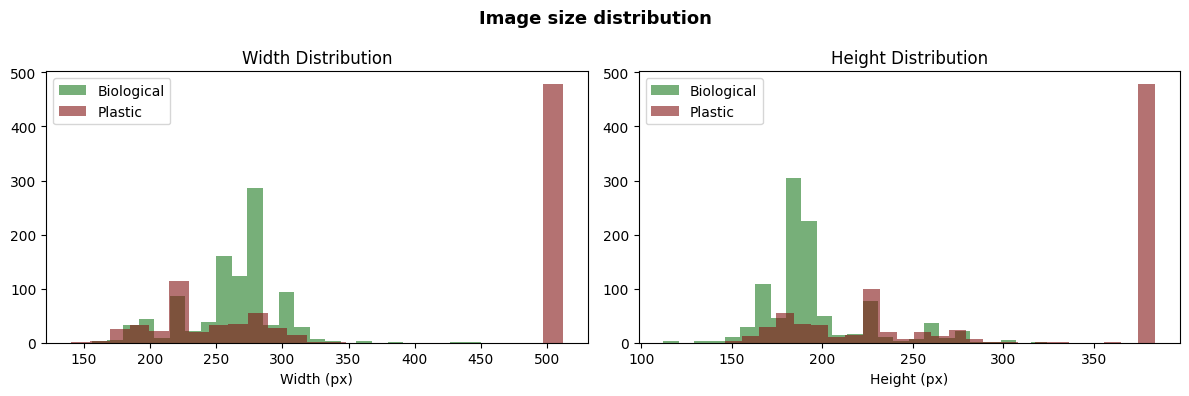

In [14]:
# Size distribution plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Image size distribution', fontsize=13, fontweight='bold')

axes[0].hist(bw, bins=25, alpha=0.6, color="#1D7B20", label='Biological')
axes[0].hist(pw, bins=25, alpha=0.6, color="#821414", label='Plastic')
axes[0].set_title('Width Distribution')
axes[0].set_xlabel('Width (px)')
axes[0].legend()

axes[1].hist(bh, bins=25, alpha=0.6, color="#1D7B20", label='Biological')
axes[1].hist(ph, bins=25, alpha=0.6, color="#821414", label='Plastic')
axes[1].set_title('Height Distribution')
axes[1].set_xlabel('Height (px)')
axes[1].legend()

plt.tight_layout()
plt.show()

Sampling pixels (may take ~10 sec)...


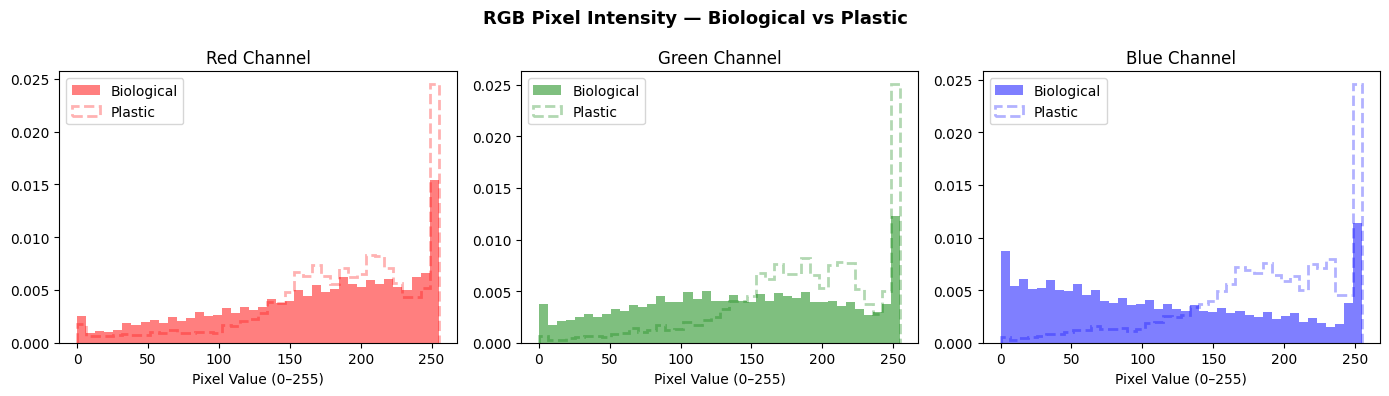

In [ ]:
# RGB pixel intensity
def get_rgb(paths, n=50):
    r, g, b = [], [], []
    for path in random.sample(paths, min(n, len(paths))):
        try:
            arr = np.array(
                Image.open(path).convert('RGB').resize((64, 64))
            )
            r.extend(arr[:, :, 0].flatten())
            g.extend(arr[:, :, 1].flatten())
            b.extend(arr[:, :, 2].flatten())
        except:
            pass
    return r, g, b

br, bg, bb = get_rgb(bio_paths)
pr, pg, pb = get_rgb(pla_paths)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('RGB Pixel Intensity — Biological vs Plastic',
             fontsize=13, fontweight='bold')

for ax, bvals, pvals, ch, col in zip(
    axes,
    [br, bg, bb], [pr, pg, pb],
    ['Red', 'Green', 'Blue'],
    ['red', 'green', 'blue']
):
    ax.hist(bvals, bins=40, alpha=0.5, color=col,
            label='Biological', density=True)
    ax.hist(pvals, bins=40, alpha=0.3, color=col,
            label='Plastic', density=True,
            linestyle='--', histtype='step', linewidth=2)
    ax.set_title(f'{ch} Channel')
    ax.set_xlabel('Pixel Value (0–255)')
    ax.legend()

plt.tight_layout()
plt.show()

In [16]:
need = len(bio_paths) - len(pla_paths)
target   = max(len(bio_paths), len(pla_paths))

print('=' * 52)
print('        EDA SUMMARY — SMART BIN PROJECT')
print('=' * 52)
print(f'  Biological images  : {len(bio_paths)} ({len(bio_paths)/total*100:.1f}%)')
print(f'  Plastic images     : {len(pla_paths)} ({len(pla_paths)/total*100:.1f}%)')
print(f'  Total images       : {total}')
print(f'  Class gap          : {need} images')
print(f'  Unique bio sizes   : {len(set(zip(bw, bh)))}')
print(f'  Unique pla sizes   : {len(set(zip(pw, ph)))}')
print('-' * 52)

        EDA SUMMARY — SMART BIN PROJECT
  Biological images  : 985 (53.2%)
  Plastic images     : 865 (46.8%)
  Total images       : 1850
  Class gap          : 120 images
  Unique bio sizes   : 184
  Unique pla sizes   : 138
----------------------------------------------------


# **Aumentation**

In [17]:
# Define augmentation Functions
def augment(img):
    choice = random.randint(1, 6)

    if choice == 1:
        return img.transpose(Image.FLIP_LEFT_RIGHT)     # Horizontal flip
    elif choice == 2:
        angle = random.uniform(-20, 20) # Rotation
        return img.rotate(angle, expand=False, fillcolor=(255, 255, 255))
    elif choice == 3:
        factor = random.uniform(0.6, 1.4)   # Brightness
        return ImageEnhance.Brightness(img).enhance(factor)
    elif choice == 4:
        w, h = img.size     #Zoom in
        mx, my = int(w * 0.1), int(h * 0.1)
        return img.crop((mx, my, w-mx, h-my)).resize(
            (w, h), Image.LANCZOS
        )
    elif choice == 5:
        factor = random.uniform(0.7, 1.3)       # Contrast
        return ImageEnhance.Contrast(img).enhance(factor)
    else:
        return img.transpose(Image.FLIP_TOP_BOTTOM)

In [18]:
# Generate New Images
random.seed(42)
generated = 0

sources = (pla_paths * ((need // len(pla_paths)) + 2))[:need]
random.shuffle(sources)

for i, src_path in enumerate(sources):
    try:
        img     = Image.open(src_path).convert('RGB')
        new_img = augment(img)
        filename  = f'aug_{i+1:04d}.jpg'
        save_path = os.path.join(plastic_dir, filename)
        new_img.save(save_path, 'JPEG', quality=95)
        generated += 1
    except Exception as e:
        print(f'  Skipped: {e}')

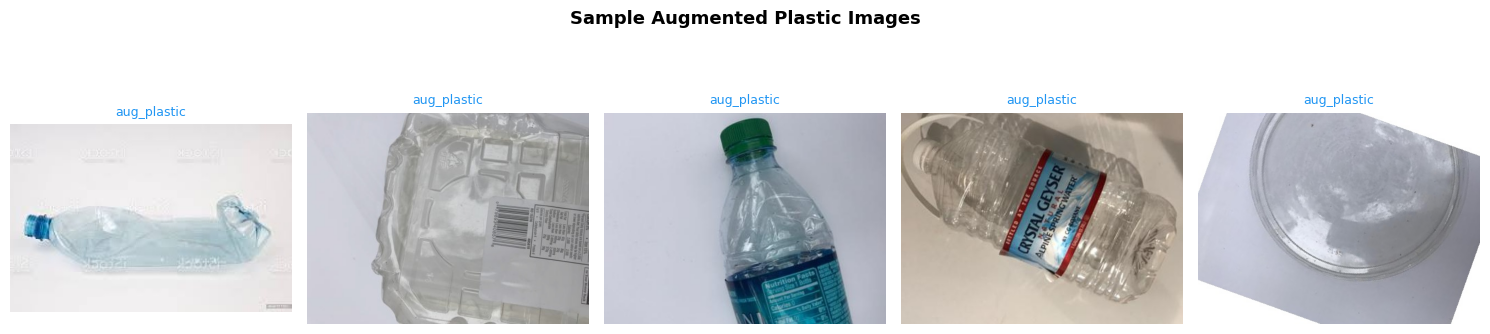

In [19]:
# Preview augmentation images
aug_paths = [
    os.path.join(plastic_dir, f)
    for f in os.listdir(plastic_dir)
    if f.startswith('aug_')
]

samples = random.sample(aug_paths, min(5, len(aug_paths)))

fig, axes = plt.subplots(1, 5, figsize=(15, 4))
fig.suptitle('Sample Augmented Plastic Images',
             fontsize=13, fontweight='bold')

for ax, path in zip(axes, samples):
    ax.imshow(Image.open(path).convert('RGB'))
    ax.axis('off')
    ax.set_title('aug_plastic', color='#2196F3', fontsize=9)

plt.tight_layout()
plt.show()

     FINAL BALANCE — AFTER AUGMENTATION
  Biological : 985 (50.0%)
  Plastic    : 985 (50.0%)
  Total      : 1970


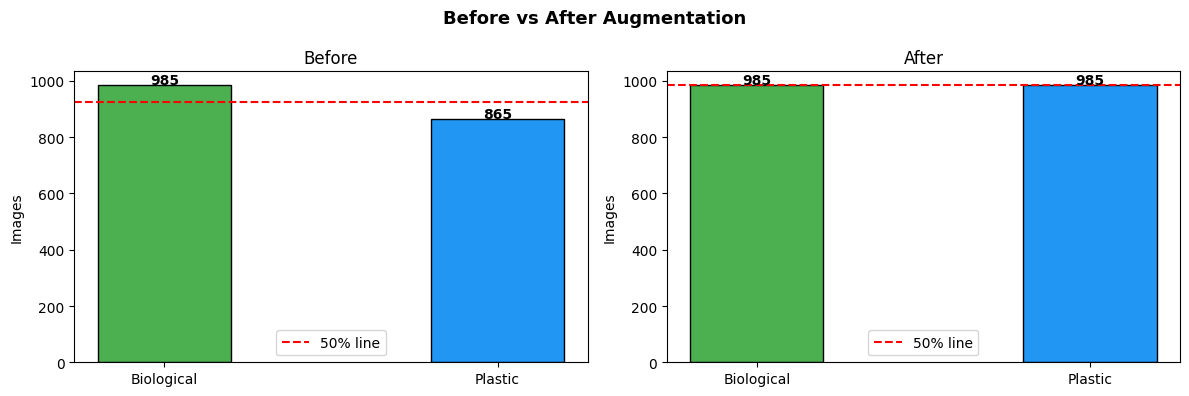

In [20]:
# Final balance check
final_bio   = len(get_paths(biological_dir))
final_pla   = len(get_paths(plastic_dir))
final_total = final_bio + final_pla

print('=' * 50)
print('     FINAL BALANCE — AFTER AUGMENTATION')
print('=' * 50)
print(f'  Biological : {final_bio} ({final_bio/final_total*100:.1f}%)')
print(f'  Plastic    : {final_pla} ({final_pla/final_total*100:.1f}%)')
print(f'  Total      : {final_total}')
print('=' * 50)

# Before vs After chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Before vs After Augmentation', fontsize=13, fontweight='bold')

# Before
b1 = axes[0].bar(['Biological', 'Plastic'],
                  [len(bio_paths), len(pla_paths)],
                  color=['#4CAF50', '#2196F3'],
                  edgecolor='black', width=0.4)
axes[0].axhline(total / 2, color='red', linestyle='--', label='50% line')
axes[0].set_title('Before')
axes[0].set_ylabel('Images')
axes[0].legend()
for bar in b1:
    axes[0].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+5,
                 str(int(bar.get_height())),
                 ha='center', fontweight='bold')

# After
b2 = axes[1].bar(['Biological', 'Plastic'],
                  [final_bio, final_pla],
                  color=['#4CAF50', '#2196F3'],
                  edgecolor='black', width=0.4)
axes[1].axhline(final_total / 2, color='red', linestyle='--', label='50% line')
axes[1].set_title('After')
axes[1].set_ylabel('Images')
axes[1].legend()
for bar in b2:
    axes[1].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+5,
                 str(int(bar.get_height())),
                 ha='center', fontweight='bold')

plt.tight_layout()
plt.show()